In [21]:
# imports
import numpy as np
import matplotlib.pyplot as plt

# Question 4

In [22]:
def tmm_single_layer(n0, n1, n2, d, wavelengths):
    R = []
    T = []
    
    for lam in wavelengths:
        delta = (2 * np.pi * n1 * d) / lam
        
        # Transfer matrix elements
        S11 = np.cos(delta)
        S12 = 1j * np.sin(delta) / n1
        S21 = 1j * n1 * np.sin(delta)
        S22 = np.cos(delta)
        
        # r / t Denominator
        denom = n0*S11 + n0*n2*S12 + S21 + n2*S22
        
        # r / t
        r = (n0*S11 + n0*n2*S12 - S21 - n2*S22) / denom
        t = (2*n0) / denom
        
        R.append(np.abs(r)**2)
        T.append((n2/n0) * np.abs(t)**2)
    
    return np.array(R), np.array(T)


In [23]:
# Refractive indices
n0 = 1.0      # layer 1
n1 = 2.6      # layer 2
n2 = 1.45     # layer 3

# Thickness
d = 5e-6      

# Wavelength sweep
wavelengths = np.linspace(500e-9, 600e-9, 1000)

Run Simulation

In [24]:
R, T = tmm_single_layer(n0, n1, n2, d, wavelengths)

Plot

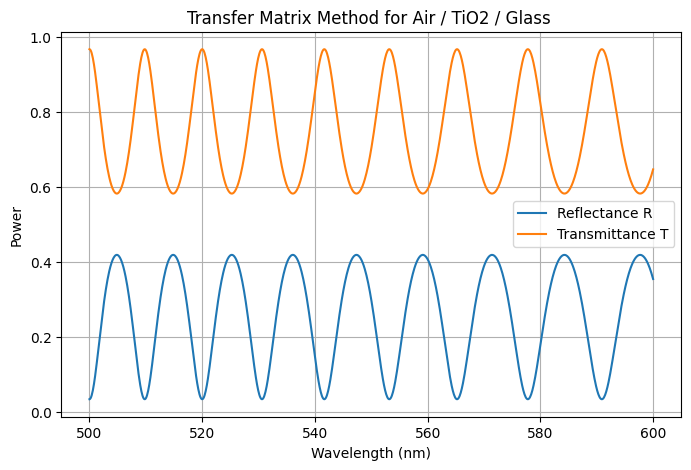

In [25]:
plt.figure(figsize=(8,5))

plt.plot(wavelengths*1e9, R, label='Reflectance R')
plt.plot(wavelengths*1e9, T, label='Transmittance T')

plt.xlabel('Wavelength (nm)')
plt.ylabel('Power')
plt.title('Transfer Matrix Method for Air / TiO2 / Glass ')
plt.legend()
plt.grid()

plt.show()

# Question 5

In [30]:
import numpy as np
import matplotlib.pyplot as plt

def layer_matrix(n, d, lam):
    delta = (2 * np.pi * n * d) / lam
    
    S11 = np.cos(delta)
    S12 = 1j * np.sin(delta) / n
    S21 = 1j * n * np.sin(delta)
    S22 = np.cos(delta)
    
    return np.array([[S11, S12],
                     [S21, S22]])

def tmm_multilayer(n_list, d_list, wavelengths):
    R = []
    T = []
    
    n0 = n_list[0]
    ns = n_list[-1]
    
    for lam in wavelengths:
        M_total = np.identity(2, dtype=complex)
        
        # multiply all layer matrices
        for i in range(len(d_list)):
            M = layer_matrix(n_list[i+1], d_list[i], lam)
            M_total = M_total @ M
        
        S11, S12 = M_total[0]
        S21, S22 = M_total[1]
        
        denom = n0*S11 + n0*ns*S12 + S21 + ns*S22
        
        r = (n0*S11 + n0*ns*S12 - S21 - ns*S22) / denom
        t = (2*n0) / denom
        
        R.append(np.abs(r)**2)
        T.append((ns/n0) * np.abs(t)**2)
    
    return np.array(R), np.array(T)

In [31]:
wavelengths = np.linspace(300e-9, 800e-9, 2000)

### Part 1
5 slabs; slab 1 has index n1=1.7 and thickness d1=100nm, and slab 2  has index n2=1.4 and thickness d2=120nm

In [32]:
n1, d1 = 1.7, 100e-9
n2, d2 = 1.4, 120e-9

pairs = 5

n_list = [1.0]  # air
d_list = []

for _ in range(pairs):
    n_list += [n1, n2]
    d_list += [d1, d2]

n_list += [1.0]  # air substrate

R1, T1 = tmm_multilayer(n_list, d_list, wavelengths)

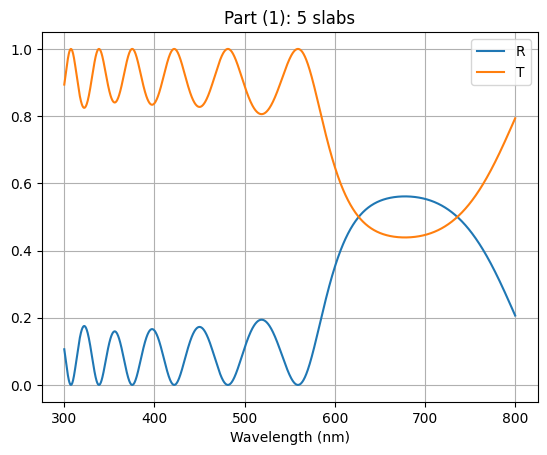

In [33]:
plt.figure()
plt.plot(wavelengths*1e9, R1, label='R')
plt.plot(wavelengths*1e9, T1, label='T')
plt.title('Part (1): 5 slabs')
plt.xlabel('Wavelength (nm)')
plt.legend()
plt.grid()
plt.show()

Comments:


### Part 2
20 pairs;  slab 1 has index n1=1.7 and thickness d1=25 nm, and slab 2  has index n2=1.4 and thickness d2=30nm

simulation:

In [34]:
n1, d1 = 1.7, 25e-9
n2, d2 = 1.4, 30e-9

pairs = 20

n_list = [1.0]
d_list = []

for _ in range(pairs):
    n_list += [n1, n2]
    d_list += [d1, d2]

n_list += [1.0]

R2, T2 = tmm_multilayer(n_list, d_list, wavelengths)

plot:

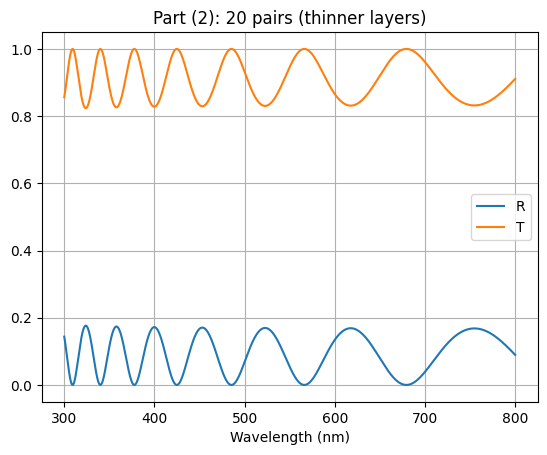

In [35]:
plt.figure()
plt.plot(wavelengths*1e9, R2, label='R')
plt.plot(wavelengths*1e9, T2, label='T')
plt.title('Part (2): 20 pairs (thinner layers)')
plt.xlabel('Wavelength (nm)')
plt.legend()
plt.grid()
plt.show()

### Part 3
effective index

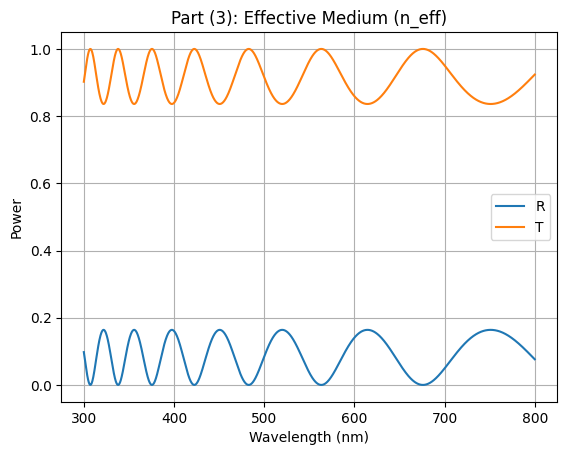

In [42]:
# Effective index
n1, d1 = 1.7, 25e-9
n2, d2 = 1.4, 30e-9

n_eff = (n1*d1 + n2*d2) / (d1 + d2)

# Total thickness 
total_thickness = 20 * (d1 + d2)


n_list_eff = [1.0, n_eff, 1.0]
d_list_eff = [total_thickness]

# TMM
R3, T3 = tmm_multilayer(n_list_eff, d_list_eff, wavelengths)

# Plot 
plt.figure()
plt.plot(wavelengths*1e9, R3, label='R')
plt.plot(wavelengths*1e9, T3, label='T')

plt.title('Part (3): Effective Medium (n_eff)')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Power')
plt.legend()
plt.grid()
plt.show()

### Part 4
bandgap design

In [43]:
lam0 = 650e-9

n1 = 2.5   # try higher contrast (key for bandgap)
n2 = 1.4

d1 = lam0 / (4*n1)
d2 = lam0 / (4*n2)

pairs = 5

In [44]:
n_list = [1.0]
d_list = []

for _ in range(pairs):
    n_list += [n1, n2]
    d_list += [d1, d2]

n_list += [1.0]

R4, T4 = tmm_multilayer(n_list, d_list, wavelengths)

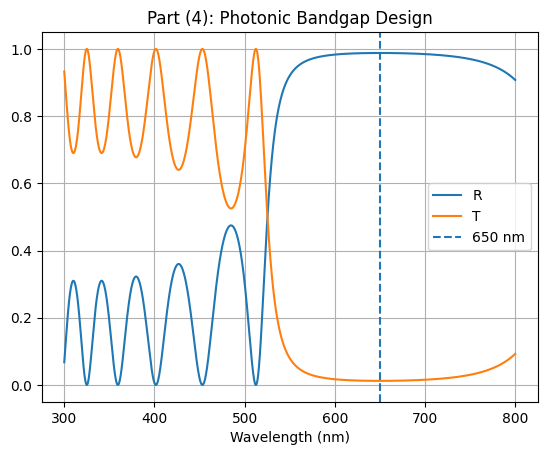

In [45]:
plt.figure()
plt.plot(wavelengths*1e9, R4, label='R')
plt.plot(wavelengths*1e9, T4, label='T')

plt.axvline(650, linestyle='--', label='650 nm')

plt.title('Part (4): Photonic Bandgap Design')
plt.xlabel('Wavelength (nm)')
plt.legend()
plt.grid()
plt.show()

## Bonus 
### Part 1
R, T for air-glass interface (set middle layer thickness =0)

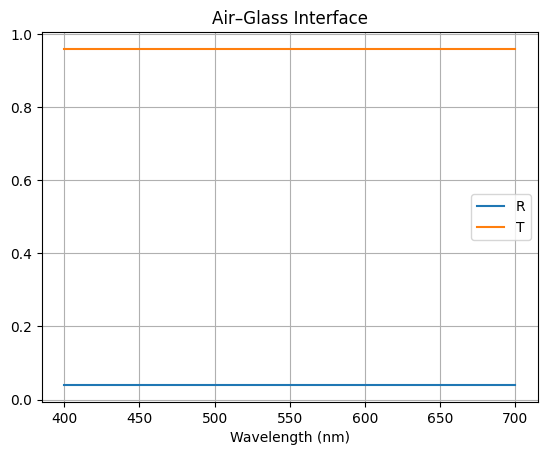

R1: 0.04000000000000001


In [66]:
n0 = 1.0
ns = 1.5

wavelengths = np.linspace(400e-9, 700e-9, 1000)

R1 = np.ones_like(wavelengths) * ((n0 - ns)/(n0 + ns))**2
T1 = 1 - R1

plt.figure()
plt.plot(wavelengths*1e9, R1, label='R')
plt.plot(wavelengths*1e9, T1, label='T')
plt.title('Air–Glass Interface')
plt.xlabel('Wavelength (nm)')
plt.legend()
plt.grid()
plt.show()

print(f'R1: {R1[0]}')

Comments: The TMM result matches the Fresnel equations, giving a constant reflectance of 4% across all wavelengths 

### Part 2
 minimize the average reflection in the entire visible wavelength range

In [67]:
def layer_matrix(n, d, lam):
    delta = (2 * np.pi * n * d) / lam
    S11 = np.cos(delta)
    S12 = 1j * np.sin(delta) / n
    S21 = 1j * n * np.sin(delta)
    S22 = np.cos(delta)
    return np.array([[S11, S12], [S21, S22]])

def tmm_multilayer(n_list, d_list, wavelengths):
    R, T = [], []
    n0, ns = n_list[0], n_list[-1]
    for lam in wavelengths:
        M = np.identity(2, dtype=complex)
        for i in range(len(d_list)):
            M = M @ layer_matrix(n_list[i+1], d_list[i], lam)
        S11, S12 = M[0]
        S21, S22 = M[1]
        denom = n0*S11 + n0*ns*S12 + S21 + ns*S22
        r = (n0*S11 + n0*ns*S12 - S21 - ns*S22) / denom
        t = (2*n0) / denom
        R.append(np.abs(r)**2)
        T.append((ns/n0) * np.abs(t)**2)
    return np.array(R), np.array(T)

wavelengths_bonus = np.linspace(400e-9, 700e-9, 1000)

n0, ns = 1.0, 1.5


R_tmm, T_tmm = tmm_multilayer([n0, 1.5, ns], [1e-12], wavelengths_bonus)

# Fresnel result
R_fresnel = ((n0 - ns) / (n0 + ns))**2
T_fresnel = 1 - R_fresnel

print(f"TMM avg R = {np.mean(R_tmm):.6f},  Fresnel R = {R_fresnel:.6f}")
print(f"TMM avg T = {np.mean(T_tmm):.6f},  Fresnel T = {T_fresnel:.6f}")



TMM avg R = 0.040000,  Fresnel R = 0.040000
TMM avg T = 0.960000,  Fresnel T = 0.960000


### Part 3
 add an imaginary part to the refractive index of the middle layer

In [68]:
n0, ns   = 1.0, 1.5
n_c      = 1.3              
lam0     = 550e-9
d_coat   = lam0 / (4 * n_c) # quarter-wave thickness

def avg_T_kappa(kappa):
    n_complex = n_c + 1j * kappa
    n_list = [n0, n_complex, ns]
    _, T = tmm_multilayer(n_list, [d_coat], wavelengths_bonus)
    return float(np.mean(T))

T0 = avg_T_kappa(0.0)   # lossless

kappa_vals = np.linspace(0, 2.0, 500)
T_avg_vals = np.array([avg_T_kappa(k) for k in kappa_vals])

target = 0.90 * T0      # 10 % drop

# Find first κ where avg T ≤ target
idx = np.where(T_avg_vals <= target)[0]
kappa_target = kappa_vals[idx[0]] if len(idx) > 0 else None

print(f"\nBonus Part 3:")
print(f"  Lossless avg T (κ=0) : {T0:.5f}")
print(f"  Target avg T (−10%)  : {target:.5f}")
if kappa_target is not None:
    print(f"  κ for 10% reduction  : {kappa_target:.4f}")
else:
    print("  κ not found in scanned range ")




Bonus Part 3:
  Lossless avg T (κ=0) : 0.99394
  Target avg T (−10%)  : 0.89455
  κ for 10% reduction  : 1.4269
